In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [2]:
File_Path = '../data/대구광역시_시군구별 수도 사용량_20250416.csv'
DF = pd.read_csv(File_Path)
DF.head()

,시군구코드,시도명,시군구명,법정동코드,동면리명,상수도주업종,연도,월,수도사용량
0,27110,대구광역시,중구,10100,동인동1가,가정용,2010,1,8095
1,27110,대구광역시,중구,10100,동인동1가,가정용,2010,2,8702
2,27110,대구광역시,중구,10100,동인동1가,가정용,2010,3,8538
3,27110,대구광역시,중구,10100,동인동1가,가정용,2010,4,8223
4,27110,대구광역시,중구,10100,동인동1가,가정용,2010,5,8347


- 지역별/ 상수도 업종별/ 년도/ 월별(년도별 스택) 수도사용량 추이
- 2025년 1~4월 데이터와 이전의 데이터 비교(추이 분석)
- 지역내 동별 비교
- 계절(봄, 여름, 가을, 겨울)  (3-5, 6-8, 9-11, 12-2)

In [3]:
DF.drop(labels=['시도명','시군구코드','법정동코드'], axis=1 ,inplace=True)
DF.head()

,시군구명,동면리명,상수도주업종,연도,월,수도사용량
0,중구,동인동1가,가정용,2010,1,8095
1,중구,동인동1가,가정용,2010,2,8702
2,중구,동인동1가,가정용,2010,3,8538
3,중구,동인동1가,가정용,2010,4,8223
4,중구,동인동1가,가정용,2010,5,8347


In [4]:
DF_group = DF.groupby(by=['시군구명','동면리명'])
DF_group[['수도사용량']].head(3)

,수도사용량
0,8095
1,8702
2,8538
368,1895
369,1733
...,...
132066,0
132067,0
132084,835
132085,830


In [5]:
# 군위군 삭제
DF = DF[~(DF['시군구명'] == '군위군')]
print(DF)

       시군구명     동면리명 상수도주업종    연도   월  수도사용량
0        중구    동인동1가    가정용  2010   1   8095
1        중구    동인동1가    가정용  2010   2   8702
2        중구    동인동1가    가정용  2010   3   8538
3        중구    동인동1가    가정용  2010   4   8223
4        중구    동인동1가    가정용  2010   5   8347
...     ...      ...    ...   ...  ..    ...
129029  달성군  구지면 도동리    일반용  2024  12    596
129030  달성군  구지면 도동리    일반용  2025   1    607
129031  달성군  구지면 도동리    일반용  2025   2    406
129032  달성군  구지면 도동리    일반용  2025   3    418
129033  달성군  구지면 도동리    일반용  2025   4    252

[129034 rows x 6 columns]


In [6]:
# 상수도주업종 공업용 통합
# DF['상수도주업종'] = DF['상수도주업종'].str.replace('(원인자부담)','')
# DF['상수도주업종'] = DF['상수도주업종'].str.replace('(원인자 미부담)','')
# 공업용(원인자부담), 공업용(원인자 미부담) → 공업용
DF['상수도주업종'] = DF['상수도주업종'].str.replace('(원인자부담)', '', regex=False)
DF['상수도주업종'] = DF['상수도주업종'].str.replace('(원인자 미부담)', '', regex=False)
DF['상수도주업종'] = DF['상수도주업종'].str.strip()  # 혹시 공백 남은 경우 제거

# '공업용'이 들어간 모든 데이터 행 확인
print(DF['상수도주업종'].str.contains('공업용'))

print(DF['상수도주업종'].unique())

# 또는 NaN 포함 여부만 확인
print(DF['상수도주업종'].isna().sum())

0         False
1         False
2         False
3         False
4         False
          ...  
129029    False
129030    False
129031    False
129032    False
129033    False
Name: 상수도주업종, Length: 129034, dtype: bool
['가정용' '일반용' '욕탕용' '공업용']
0


C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_33600\406835148.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF['상수도주업종'] = DF['상수도주업종'].str.replace('(원인자부담)', '', regex=False)
C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_33600\406835148.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF['상수도주업종'] = DF['상수도주업종'].str.replace('(원인자 미부담)', '', regex=False)
C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_33600\406835148.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [7]:
# '달성군' + 업종 4개 필터링
target_types = ['가정용', '일반용', '욕탕용', '공업용']
df_dsg = DF[(DF['시군구명'] == '달성군') & (DF['상수도주업종'].isin(target_types))]

# 업종별 수도사용량 확인
usage_by_type = df_dsg.groupby('상수도주업종')['수도사용량'].sum().sort_values(ascending=False)
print(usage_by_type)

상수도주업종
가정용    242646470
일반용    152545324
공업용     68127785
욕탕용      3522468
Name: 수도사용량, dtype: int64


In [8]:
# 올바른 방법: 정규식으로 괄호 안 텍스트 제거
DF['상수도주업종'] = DF['상수도주업종'].str.replace(r'\(.*?\)', '', regex=True)
DF['상수도주업종'] = DF['상수도주업종'].str.strip()

# 원하는 업종
target_types = ['가정용', '일반용', '욕탕용', '공업용']

# 달성군 + 업종 필터링
df_dsg = DF[(DF['시군구명'] == '달성군') & (DF['상수도주업종'].isin(target_types))]

# 업종별 수도 사용량 집계
usage_by_type = df_dsg.groupby('상수도주업종')['수도사용량'].sum()
print(usage_by_type)

상수도주업종
가정용    242646470
공업용     68127785
욕탕용      3522468
일반용    152545324
Name: 수도사용량, dtype: int64


C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_33600\3068954899.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF['상수도주업종'] = DF['상수도주업종'].str.replace(r'\(.*?\)', '', regex=True)
C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_33600\3068954899.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF['상수도주업종'] = DF['상수도주업종'].str.strip()


In [9]:
# 1. 상수도업종별 => 파이그래프
# 2. 연도별(월별) : 그래프 같이 보이게 : 수도사용량 => 꺾은선그래프
# 3. 읍면리동으로 구분 : 수도사용량 => 꺾은선그래프 또는 막대그래프 (예쁜거 선택)
# 4. 계절별(3-5, 6-8, 9-11, 12-2) : 수도사용량 => 막대그래프

In [10]:
print(DF)

       시군구명     동면리명 상수도주업종    연도   월  수도사용량
0        중구    동인동1가    가정용  2010   1   8095
1        중구    동인동1가    가정용  2010   2   8702
2        중구    동인동1가    가정용  2010   3   8538
3        중구    동인동1가    가정용  2010   4   8223
4        중구    동인동1가    가정용  2010   5   8347
...     ...      ...    ...   ...  ..    ...
129029  달성군  구지면 도동리    일반용  2024  12    596
129030  달성군  구지면 도동리    일반용  2025   1    607
129031  달성군  구지면 도동리    일반용  2025   2    406
129032  달성군  구지면 도동리    일반용  2025   3    418
129033  달성군  구지면 도동리    일반용  2025   4    252

[129034 rows x 6 columns]


In [11]:
DF['상수도주업종'].unique()

array(['가정용', '일반용', '욕탕용', '공업용'], dtype=object)

In [12]:
# '달성군'만 필터링
df_dsg = DF[DF['시군구명'] == '달성군']

In [13]:
# 세부지역(동면리명)별 수도 사용량 합계 계산
usage_by_region = df_dsg.groupby('동면리명')['수도사용량'].sum()

In [ ]:
# 수도 사용량 기준 상위 10개 지역 추출
top10 = usage_by_region.sort_values(ascending=False).head(10)        
print(top10)

동면리명
논공읍 본리리    62494630
논공읍 북리     47392884
다사읍 매곡리    37036794
화원읍 천내리    35676215
다사읍 서재리    26548803
다사읍 죽곡리    22629815
화원읍 명곡리    17399565
다사읍 세천리    16362326
유가읍 봉리     16262719
현풍읍 중리     14547634
Name: 수도사용량, dtype: int64


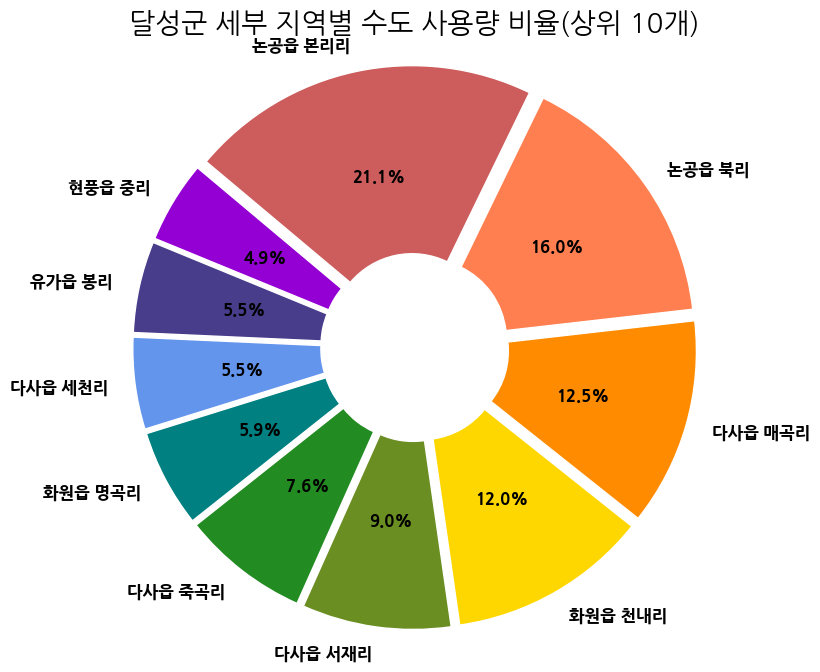

In [ ]:
# 파이차트 그리기
plt.figure(figsize=(8,8))

# 파이차트 간격
explode = [0.05] * 10

# 표 꾸미기
plt.pie(top10,
        labels=top10.index,
        explode = explode,
        autopct='%.1f%%',
        startangle=140,
        counterclock=False,
        colors = ['indianred', 'coral', 'darkorange', 'gold',
                   'olivedrab', 'forestgreen', 'teal', 'cornflowerblue',
                   'darkslateblue', 'darkviolet'],
        textprops={'fontsize': 12, 'fontweight': 'bold'},  # 폰트 설정
        wedgeprops={'width':0.7, 'edgecolor':'w','linewidth':1 })
plt.title('달성군 세부 지역별 수도 사용량 비율(상위 10개)', fontsize=20)
plt.axis('equal') # 원형 유지
plt.show()

C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_33600\817311939.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dsg['행정단위'] = df_dsg['동면리명'].str.split().str[0]


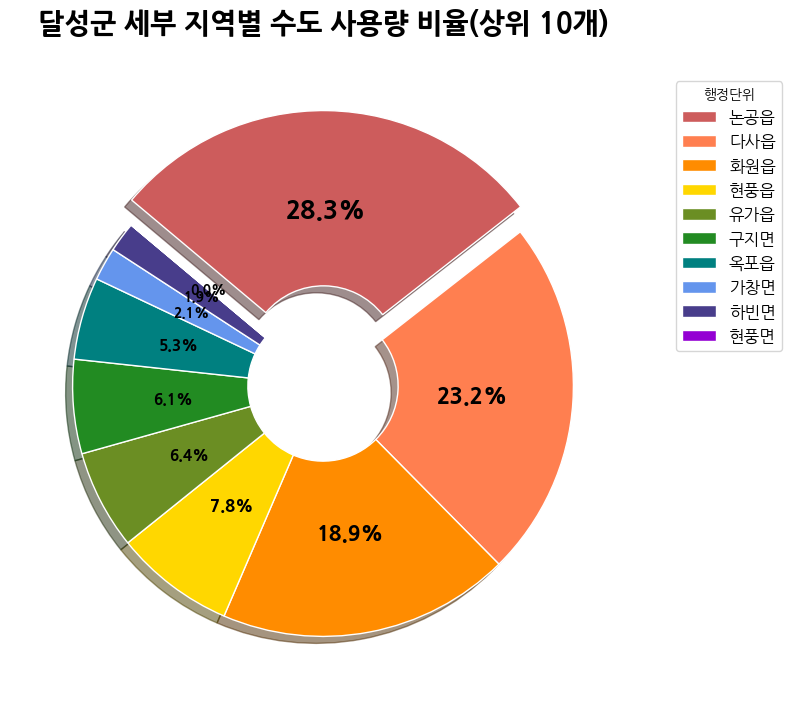

In [83]:
# (1) '동면리명'에서 앞 단어만 추출하여 '행정단위'로 통합
df_dsg['행정단위'] = df_dsg['동면리명'].str.split().str[0]

# (2) 행정단위별 수도사용량 합계
usage_by_unit = df_dsg.groupby('행정단위')['수도사용량'].sum()

# (3) 상위 10개 지역만 추출
top10 = usage_by_unit.sort_values(ascending=False).head(10)

# (4) 가장 큰 조각만 강조
explode = [0.1 if i == 0 else 0 for i in range(len(top10))]

# (5) 사용량 기준으로 동적 폰트 크기 설정
usage_values = top10.values
min_font = 10
max_font = 18
scaled_fonts = ((usage_values - usage_values.min()) / (usage_values.max() - usage_values.min()) * (max_font - min_font) + min_font).astype(int)

# (6) 파이차트 그리기
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(top10,
        labels=['']*len(top10),  # 동 이름 라벨 제거
        explode=explode,
        autopct='%.1f%%',
        startangle=140,
        counterclock=False,
        shadow=True,
        colors=['indianred', 'coral', 'darkorange', 'gold',
                'olivedrab', 'forestgreen', 'teal', 'cornflowerblue',
                'darkslateblue', 'darkviolet'],
        wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 1})

# (7) 퍼센트 글자 크기 반영
for i, autotext in enumerate(autotexts):
    autotext.set_fontsize(scaled_fonts[i])
    autotext.set_fontweight('bold')

# (8) 범례를 오른쪽 상단, 제목과 겹치지 않게
ax.legend(top10.index,
          loc='upper left',
          bbox_to_anchor=(1.05, 1.0),  # ← 오른쪽 바깥으로 띄우는 위치
          frameon=True,
          fontsize=12,
          title='행정단위')

# (9) 제목 및 마무리
plt.title('달성군 세부 지역별 수도 사용량 비율(상위 10개)', fontsize=20, fontweight='bold', pad=30)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [91]:
# 수도 사용량 기준 상위 10개 지역 추출
top10 = usage_by_unit.sort_values(ascending=False).head(10)        
print(top10)

행정단위
논공읍    132245099
다사읍    108130663
화원읍     88080710
현풍읍     36225349
유가읍     29926438
구지면     28369759
옥포읍     24821691
가창면      9973313
하빈면      9066350
현풍면         2675
Name: 수도사용량, dtype: int64


In [16]:
print(DF.columns)

Index(['시군구명', '동면리명', '상수도주업종', '연도', '월', '수도사용량'], dtype='object')


C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_33600\1238455803.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF['상수도주업종'] = DF['상수도주업종'].str.replace(r'\(.*?\)', '', regex=True).str.strip()


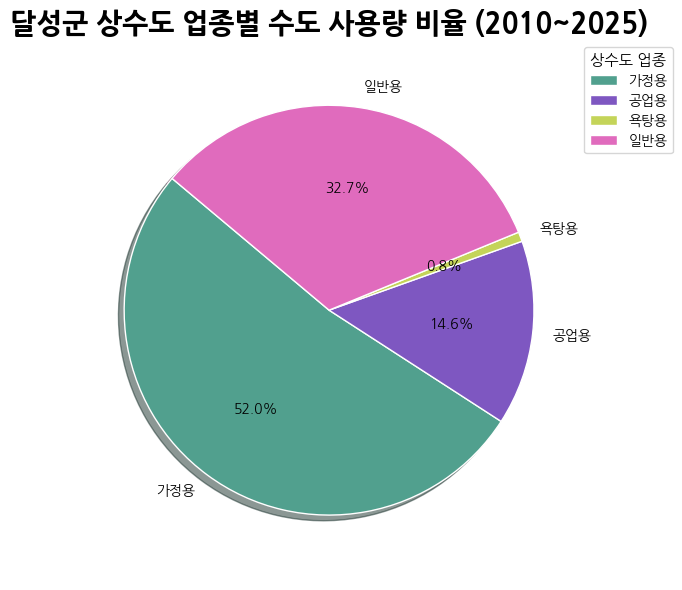

In [89]:
# 1. 상수도업종별 => 파이그래프

# '달성군' 상수도주업종 필터링
DF['상수도주업종'] = DF['상수도주업종'].str.replace(r'\(.*?\)', '', regex=True).str.strip()

# '달성군' 상수도주업종 4개 선택
target_types = ['가정용', '일반용', '욕탕용', '공업용']
df_dsg = DF[(DF['시군구명'] == '달성군') & (DF['상수도주업종'].isin(target_types))]

# 상수도주업종별 수도사용량 합계
usage_by_type = df_dsg.groupby('상수도주업종')['수도사용량'].sum()

# 파이차트 표 간격
explode = (0.1)

# 파이차트 시각화
plt.figure(figsize=(6, 6))
plt.pie(usage_by_type,
        labels=usage_by_type.index,
        autopct='%.1f%%',
        startangle=140,
        shadow=True,
        colors=["#51a08e", "#7e57c1", "#c4d459", "#e06bbd"],
        wedgeprops={'edgecolor': 'w', 'linewidth': 1})
plt.title('달성군 상수도 업종별 수도 사용량 비율 (2010~2025)', fontsize=20, fontweight='bold')

# ▶ 범례 오른쪽 상단 바깥쪽으로 이동
plt.legend(title='상수도 업종',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           fontsize=10,
           title_fontsize=11)

plt.axis('equal')
plt.tight_layout()
plt.show()

In [18]:
print(usage_by_type)

상수도주업종
가정용    242646470
공업용     68127785
욕탕용      3522468
일반용    152545324
Name: 수도사용량, dtype: int64


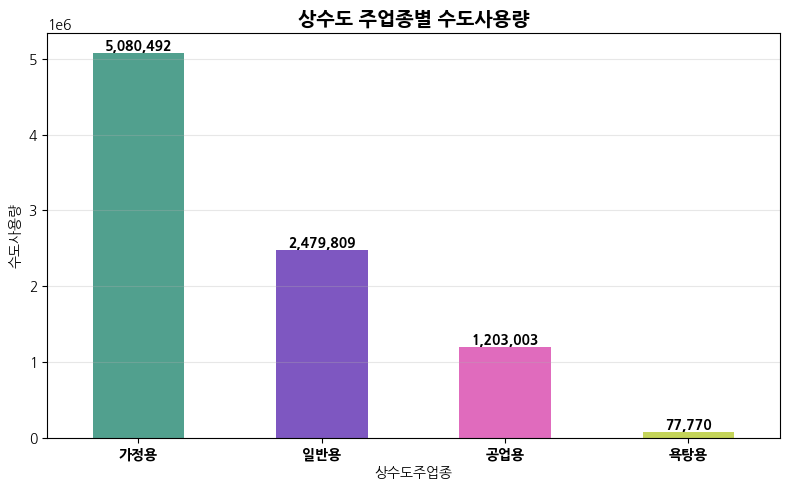

In [54]:
# 상수도주업종 수도사용량

# 막대 높이가 큰 순서로 정렬
s = usage_by_type.sort_values(ascending=False)

ax = s.plot(kind='bar', figsize=(8,5), 
            color=['#51a08e', '#7e57c1', '#e06bbd', '#c4d459'])
ax.set_title('상수도 주업종별 수도사용량', fontsize=14, fontweight='bold')
ax.set_xlabel('상수도주업종')
ax.set_ylabel('수도사용량')
ax.grid(axis='y', alpha=0.3)

# X축 라벨 방향 → 가로 방향
plt.xticks(rotation=0, fontweight='bold')

# 값 라벨 표시
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),
            f'{int(p.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


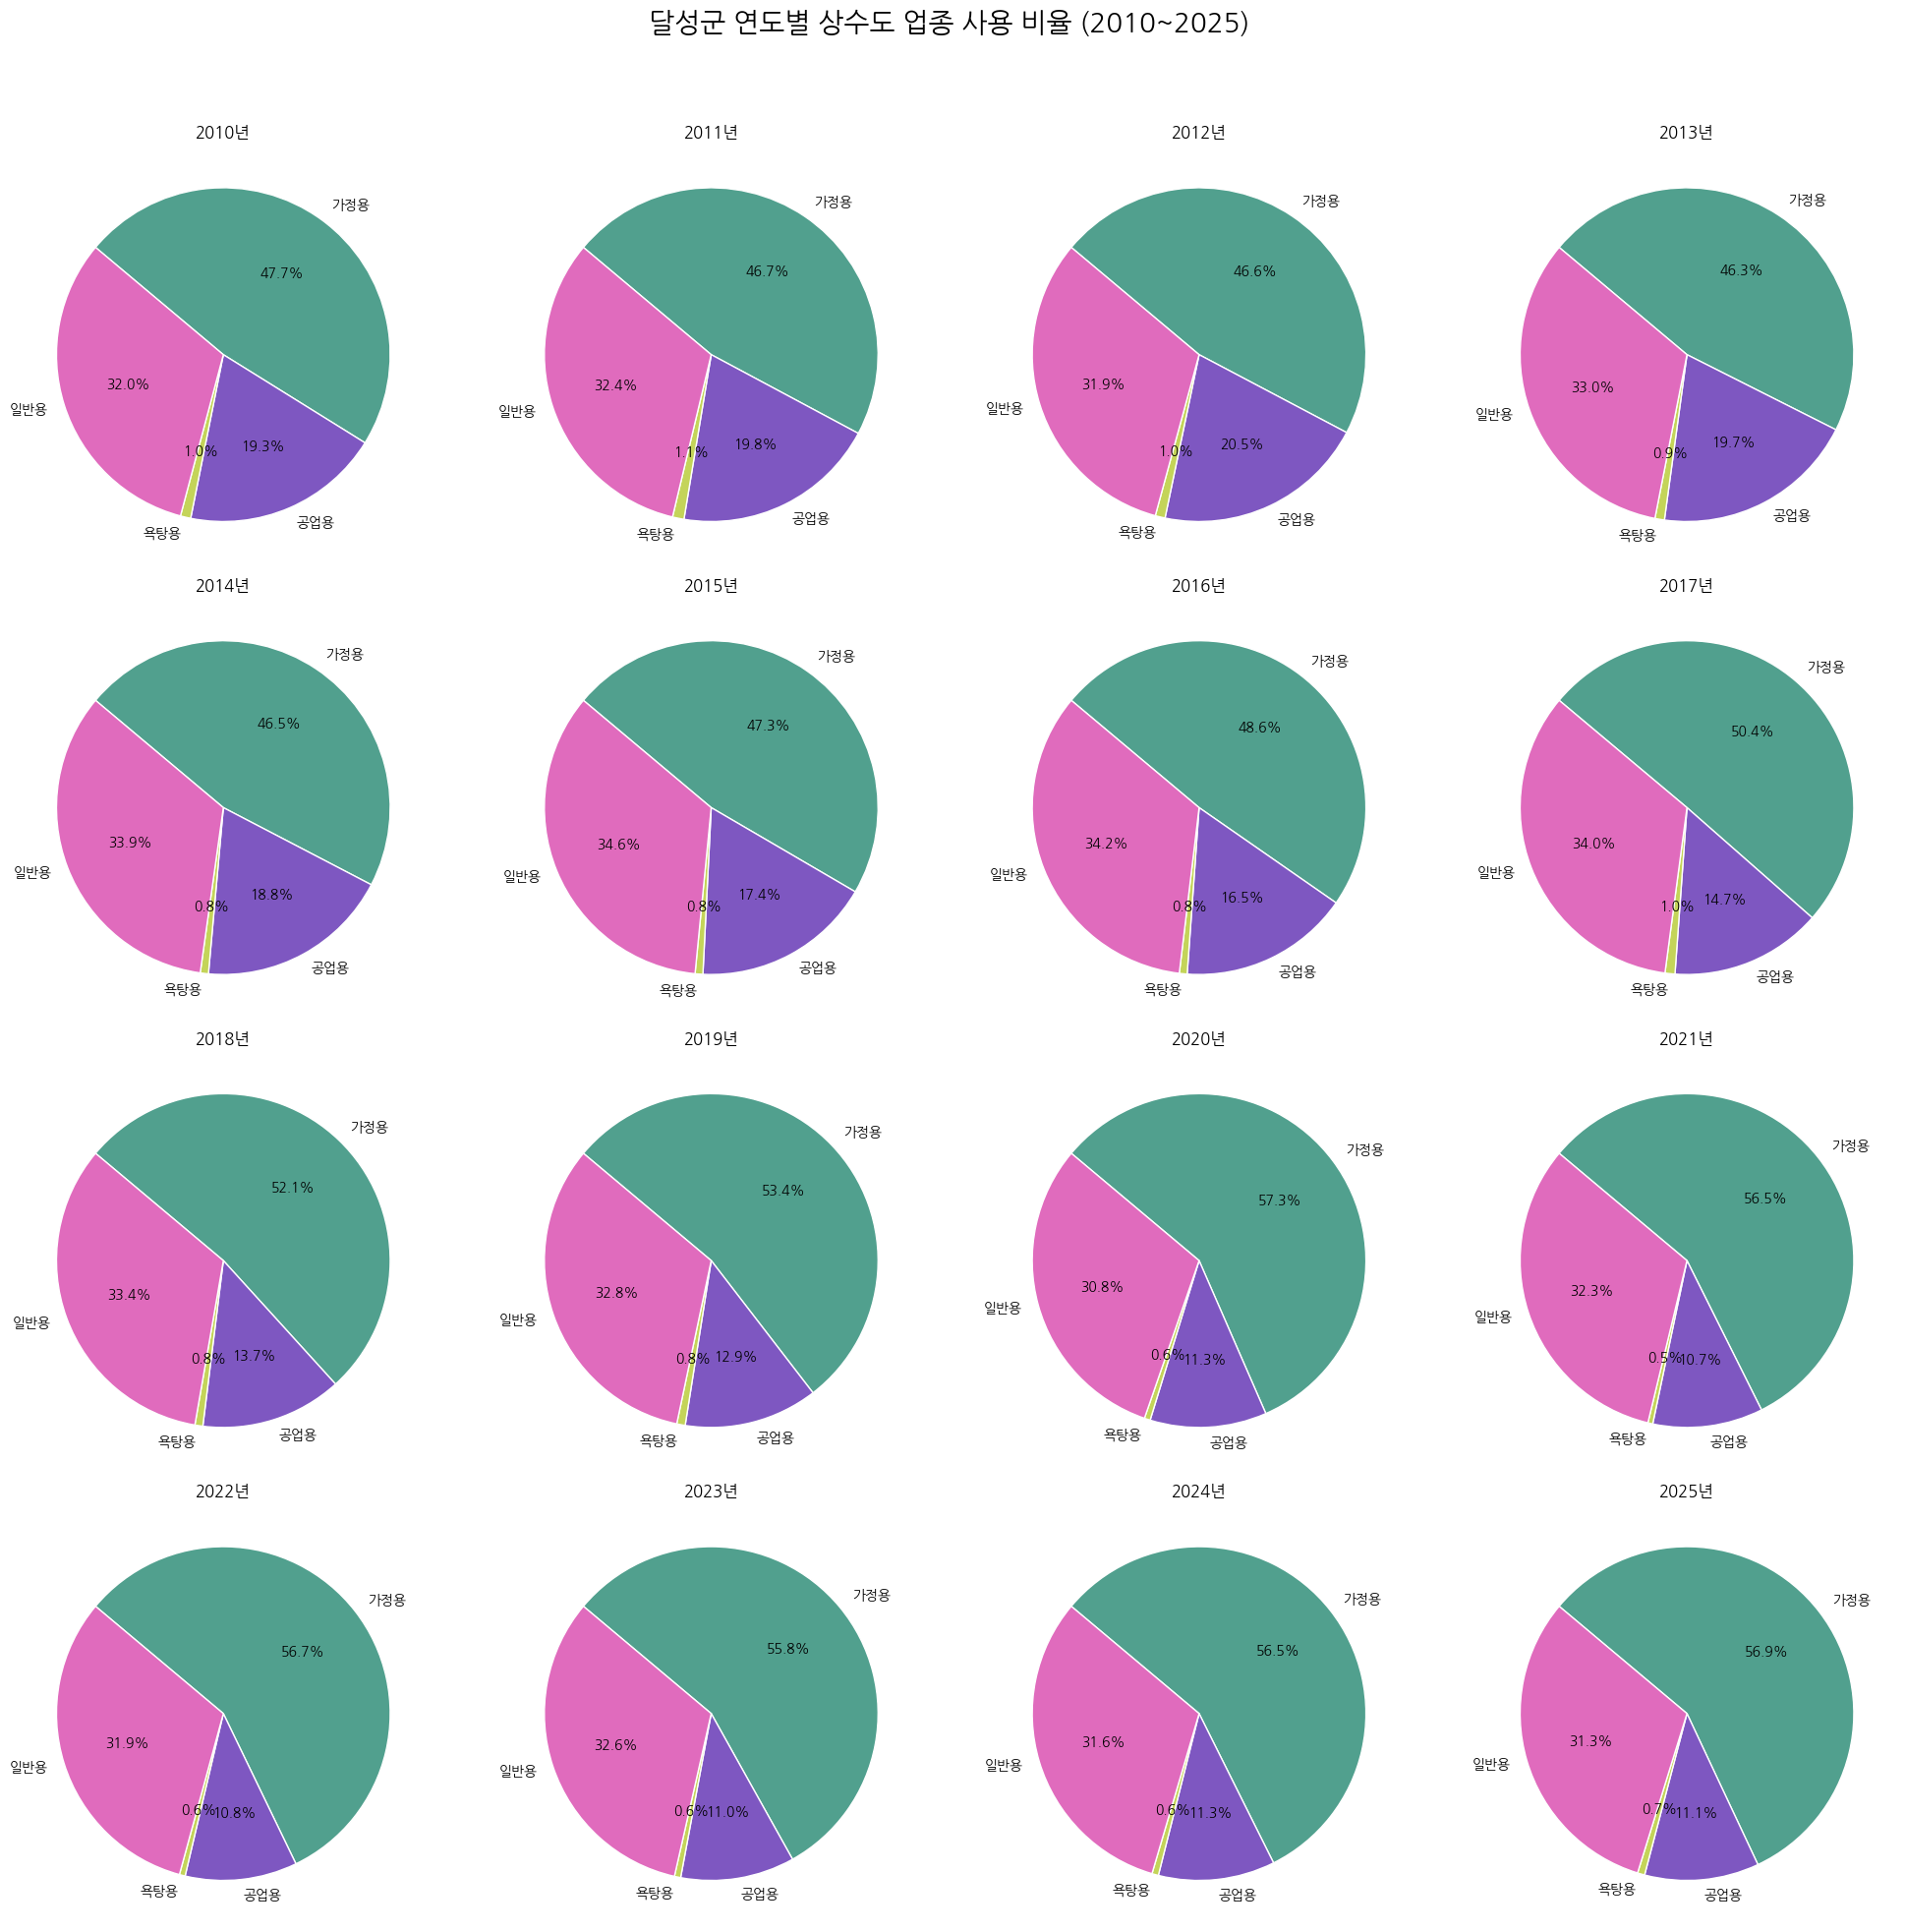

In [87]:
# 대상 업종만 필터링
target_types = ['가정용', '일반용', '욕탕용', '공업용']
df_dsg = df_dsg[df_dsg['상수도주업종'].isin(target_types)]

# 분석 연도
target_years = list(range(2010, 2026))  # 2010 ~ 2025

# 서브플롯 준비 (4행 x 4열 = 16칸)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()  # 1차원 배열로 만들기

# 반복하며 연도별로 파이차트 그리기
for i, year in enumerate(target_years):
    df_year = df_dsg[df_dsg['연도'] == year]

    ax = axes[i]  # subplot 선택

    if df_year.empty:
        ax.axis('off')  # 데이터 없으면 공백 처리
        continue

    # 업종별 수도 사용량 합계
    usage_by_type = df_year.groupby('상수도주업종')['수도사용량'].sum()

    # 파이차트
    ax.pie(usage_by_type,
           labels=usage_by_type.index,
           autopct='%.1f%%',
           startangle=140,
           counterclock=False,
           colors=["#51a08e", "#7e57c1", "#c4d459", "#e06bbd"],
           wedgeprops={'edgecolor': 'w', 'linewidth': 1})
    ax.set_title(f'{year}년')

# 남는 subplot 비우기
for j in range(len(target_years), len(axes)):
    axes[j].axis('off')

# 전체 제목 & 정렬
plt.suptitle('달성군 연도별 상수도 업종 사용 비율 (2010~2025)', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


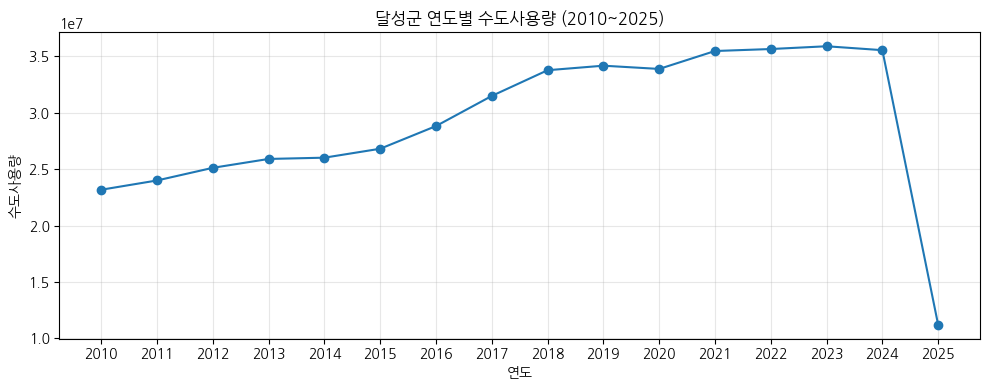

In [20]:
# 2. 연도별(월별) : 그래프 같이 보이게 : 수도사용량 => 꺾은선그래프

# '달성군' 필터링
target_years = list(range(2010, 2026))
df_dsg = DF[(DF['시군구명'] == '달성군') & (DF['연도'].isin(target_years))]

# 연도별 수도사용량 합계 계산
df_dsg_years = df_dsg.groupby('연도')['수도사용량'].sum()

# 꺾은선그래프 시각화
plt.figure(figsize=(10, 4))
plt.plot(df_dsg_years.index, df_dsg_years.values, marker='o')
plt.xlabel('연도')
plt.ylabel('수도사용량')
plt.title('달성군 연도별 수도사용량 (2010~2025)')
plt.xticks(df_dsg_years.index, rotation=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

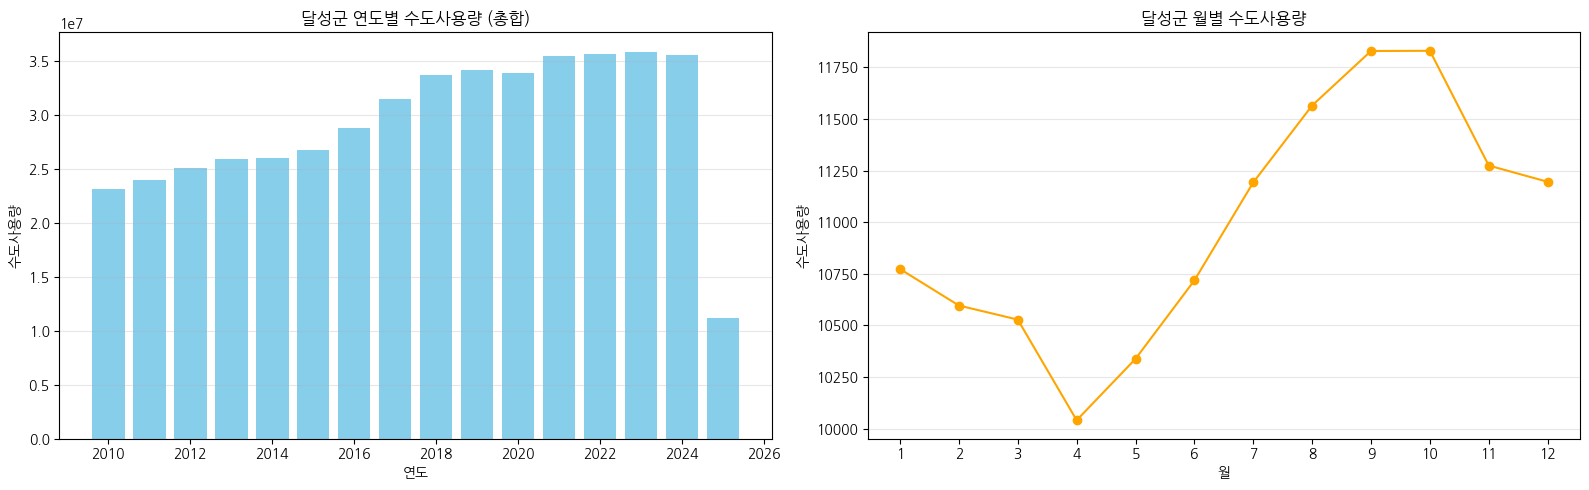

In [21]:
# 2. 연도별(월별) : 그래프 같이 보이게 : 수도사용량 => 꺾은선그래프

# (1) 연도별 총 수도사용량
yearly_usage = df_dsg.groupby('연도')['수도사용량'].sum()

# (2) 월별 평균 수도사용량
monthly_usage = df_dsg.groupby('월')['수도사용량'].mean()

# 시각화
fig, axes = plt.subplots(1,2, figsize=(16, 5))

# (1) 막대그래프
axes[0].bar(yearly_usage.index, yearly_usage.values, color='skyblue')
axes[0].set_title('달성군 연도별 수도사용량 (총합)')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('수도사용량')
axes[0].grid(axis='y', alpha=0.3)

# (2) 꺾은선 그래프
axes[1].plot(monthly_usage.index, monthly_usage.values, marker='o', color='orange')
axes[1].set_title('달성군 월별 수도사용량')
axes[1].set_xlabel('월')
axes[1].set_ylabel('수도사용량')
axes[1].set_xticks(range(1,13))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

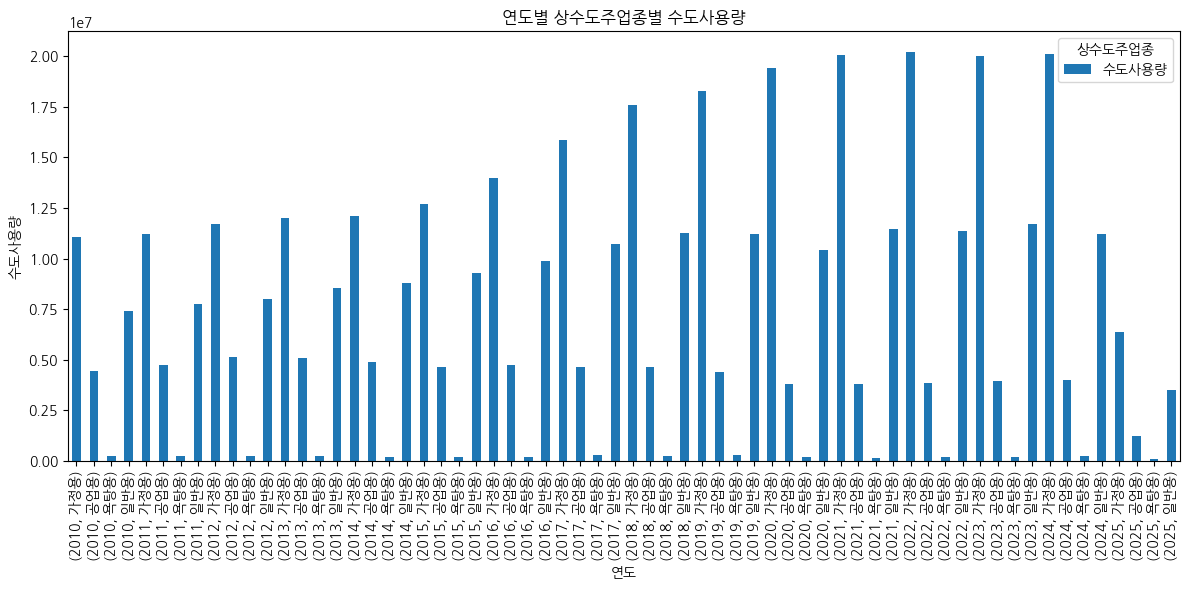

In [22]:
# 연도별 업종별 막대그래프

# 연도별 업종별 수도사용량
yearly_usage_type = df_dsg.groupby(['연도','상수도주업종'])['수도사용량'].sum()

# 막대그래프
yearly_usage_type.plot(kind='bar', figsize=(12,6))
plt.title('연도별 상수도주업종별 수도사용량')
plt.xlabel('연도')
plt.ylabel('수도사용량')
plt.legend(title='상수도주업종')
plt.tight_layout()
plt.show()


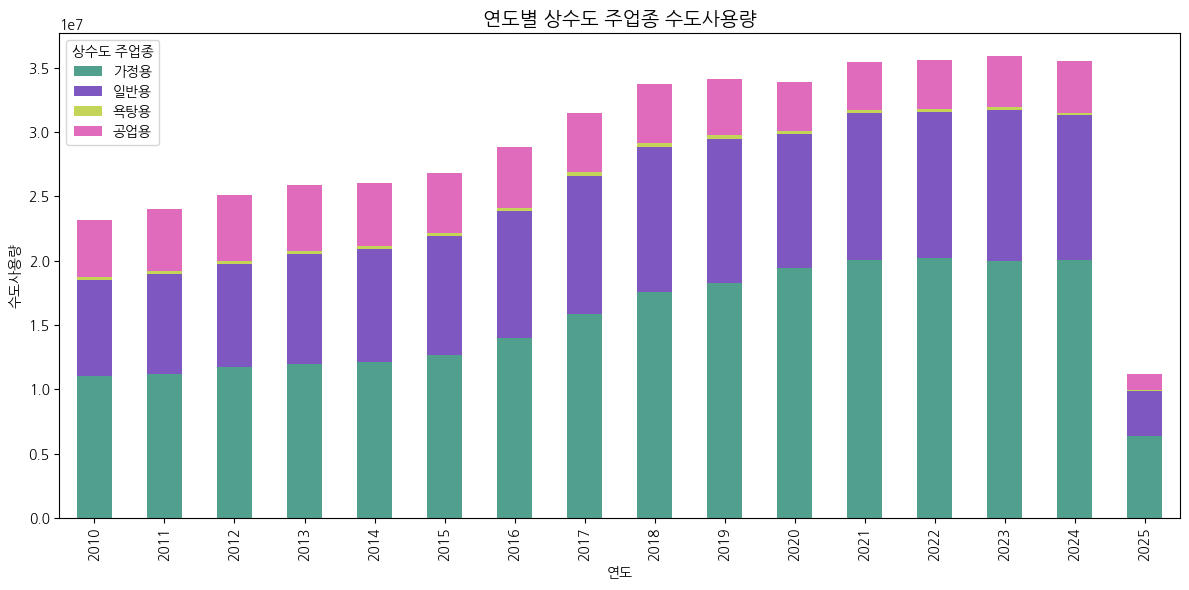

In [23]:
# 연도별 업종별 막대그래프

# 상수도 주업종 용도
# 가정용 : 음용, 조리, 세면, 목욕, 청소 등 일상생활에서 필요한 물을 공급받는 용도
# 일반용 : 가정용 외의 용도로, 소규모 상점, 사무실, 학원 등에서 사용하는 물
# 욕탕용 : 대중목욕탕, 온천 등에서 사용하는 물로, 대량의 온수
# 공장용 : 공장에서 제품 생산, 설비 가동, 세척 등에 사용되는 물

# 업종별 필터링
target_types = ['가정용', '일반용', '욕탕용', '공업용']
df_filtered = df_dsg[df_dsg['상수도주업종'].isin(target_types)]

# 연도별 업종별 수도사용량 합계
grouped = df_filtered.groupby(['연도', '상수도주업종'])['수도사용량'].sum().unstack().fillna(0)

# 그래프 그리기
grouped[target_types].plot(
    kind='bar',
    stacked=True, # 하나의 막대에 누적
    figsize=(12,6),
    color = ["#51a08e", "#7e57c1", "#c4d459", "#e06bbd"])

# 그래프 스타일 설정
plt.title('연도별 상수도 주업종 수도사용량', fontsize=14)
plt.xlabel('연도')
plt.ylabel('수도사용량')
plt.legend(title='상수도 주업종')
plt.tight_layout()
plt.show()

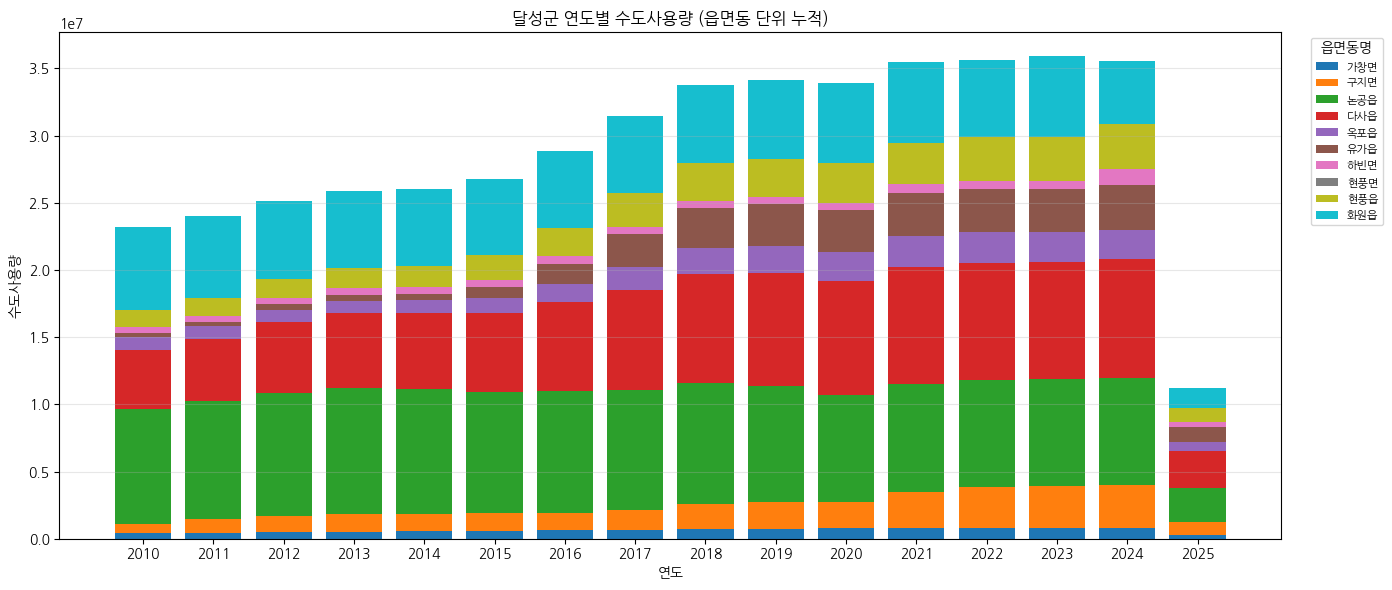

In [ ]:
# 달성군 필터링 (2010~2025)

df_dsg = DF[DF['시군구명'] == '달성군']
target_years = list(range(2010, 2026))
df_dsg = DF[(DF['시군구명'] == '달성군') & (DF['연도'].isin(target_years))].copy()

# '동면리명'에서 앞부분만 추출 → 새로운 컬럼 추가
df_dsg['행정단위'] = df_dsg['동면리명'].str.split().str[0]

# 연도별-행정단위별 수도사용량 합계 구하기
pivot_df = df_dsg.pivot_table(index='연도',
                               columns='행정단위',
                               values='수도사용량',
                               aggfunc='sum',
                               fill_value=0)

# 누적 막대그래프
plt.figure(figsize=(14, 6))


bottom = pd.Series([0]*len(pivot_df), index=pivot_df.index)

for dong in pivot_df.columns:
    plt.bar(pivot_df.index, pivot_df[dong], bottom=bottom, label=dong)
    bottom += pivot_df[dong]

# 꾸미기
plt.title('달성군 연도별 수도사용량 (읍면동 단위 누적)')
plt.xlabel('연도')
plt.ylabel('수도사용량')
plt.xticks(pivot_df.index)
plt.legend(title='읍면동명', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

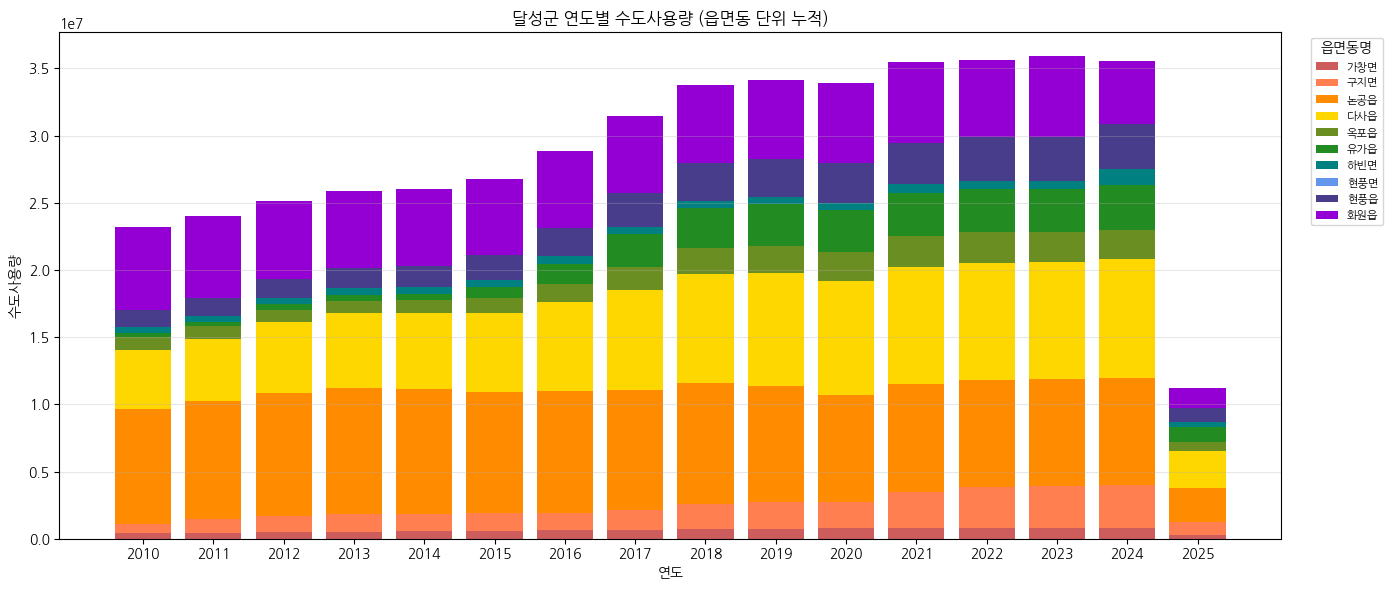

In [ ]:
# 색상 목록 (행정단위 수와 일치)
colors = ['indianred', 'coral', 'darkorange', 'gold',
          'olivedrab', 'forestgreen', 'teal', 'cornflowerblue',
          'darkslateblue', 'darkviolet']

# 누적 막대그래프
plt.figure(figsize=(14, 6))

bottom = pd.Series([0]*len(pivot_df), index=pivot_df.index)

# 행정단위별 색상 매핑
for i, dong in enumerate(pivot_df.columns):
    color = colors[i % len(colors)]  # 행정단위 수 > 색상 수일 경우를 대비해 나머지 처리
    plt.bar(pivot_df.index, pivot_df[dong], bottom=bottom, label=dong, color=color)
    bottom += pivot_df[dong]

# 꾸미기
plt.title('달성군 연도별 수도사용량 (읍면동 단위 누적)')
plt.xlabel('연도')
plt.ylabel('수도사용량')
plt.xticks(pivot_df.index)
plt.legend(title='읍면동명', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

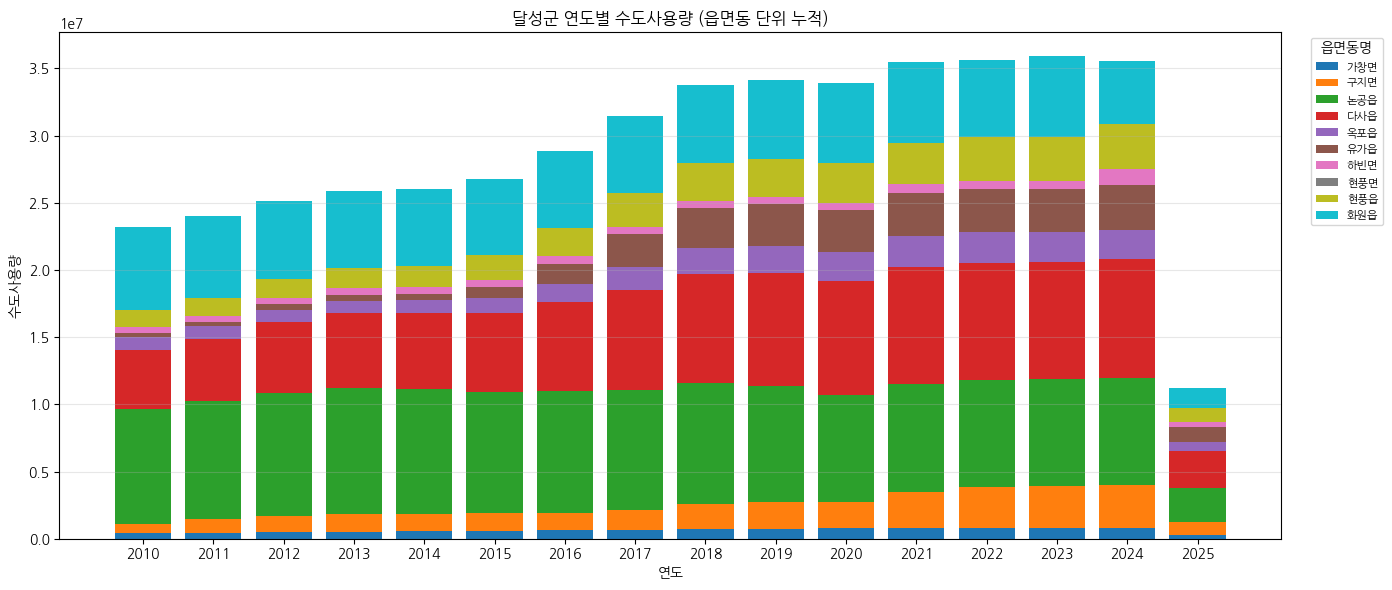

Index(['논공읍', '다사읍', '화원읍', '현풍읍', '유가읍'], dtype='object', name='행정단위')


In [25]:
# 읍면리동으로 구분 : 수도사용량 => 꺾은선그래프 또는 막대그래프 (예쁜거 선택)
# '동면리명'에서 앞부분만 추출 → 새로운 컬럼 추가
df_dsg['행정단위'] = df_dsg['동면리명'].str.split().str[0]

# 연도별-행정단위별 수도사용량 합계 구하기
pivot_df = df_dsg.pivot_table(index='연도',
                               columns='행정단위',
                               values='수도사용량',
                               aggfunc='sum',
                               fill_value=0)

# 누적 막대그래프
plt.figure(figsize=(14, 6))
bottom = pd.Series([0]*len(pivot_df), index=pivot_df.index)

for dong in pivot_df.columns:
    plt.bar(pivot_df.index, pivot_df[dong], bottom=bottom, label=dong)
    bottom += pivot_df[dong]

# 꾸미기
plt.title('달성군 연도별 수도사용량 (읍면동 단위 누적)')
plt.xlabel('연도')
plt.ylabel('수도사용량')
plt.xticks(pivot_df.index)
plt.legend(title='읍면동명', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

top_units = df_dsg.groupby('행정단위')['수도사용량'].sum().nlargest(5).index
df_dsg = df_dsg[df_dsg['행정단위'].isin(top_units)]

plt.show()
print(top_units)


NameError: name 'mdates' is not defined

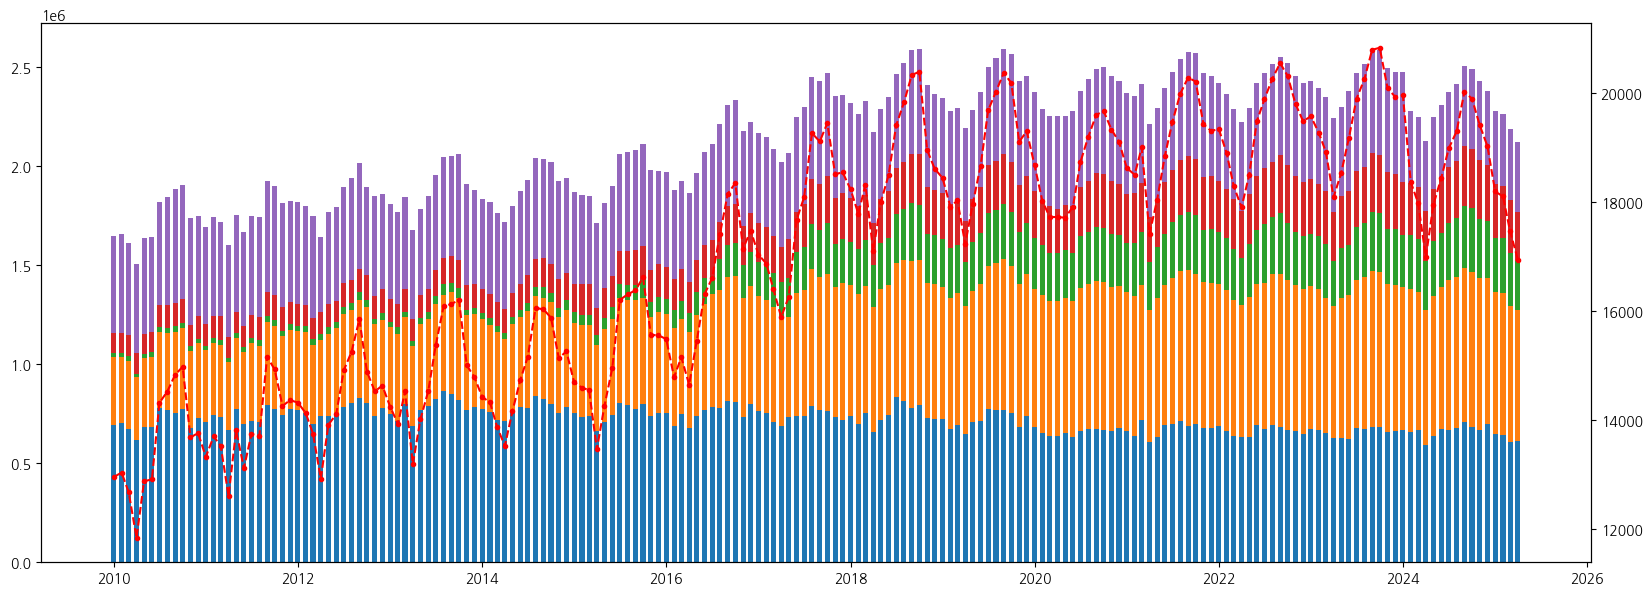

In [26]:
# 3. 읍면리동으로 구분 : 수도사용량 => 꺾은선그래프 또는 막대그래프 (예쁜거 선택)

# '연월' 컬럼 생성 (가장 중요한 부분)
# '연도'와 '월'을 문자열로 합친 후, 날짜(datetime) 형식으로 변환합니다.
df_dsg['연월'] = pd.to_datetime(df_dsg['연도'].astype(str) + '-' + df_dsg['월'].astype(str))

# '행정단위' 컬럼 생성
df_dsg['행정단위'] = df_dsg['동면리명'].str.split().str[0]

# '연월'을 기준으로 데이터 집계
# 누적 막대그래프용 데이터
pivot_df_timeseries = df_dsg.pivot_table(index='연월',
                                         columns='행정단위',
                                         values='수도사용량',
                                         aggfunc='sum',
                                         fill_value=0)
# 꺾은선그래프용 데이터
timeseries_avg = df_dsg.groupby('연월')['수도사용량'].mean()


# --- 그래프 그리기 ---
fig, ax1 = plt.subplots(figsize=(20, 7)) # 가로 길이를 늘려 시간 축이 잘 보이게 함

# 첫 번째 축(ax1)에 누적 막대그래프 그리기
bottom = pd.Series([0] * len(pivot_df_timeseries), index=pivot_df_timeseries.index)
for unit in pivot_df_timeseries.columns:
    ax1.bar(pivot_df_timeseries.index, pivot_df_timeseries[unit], width=20, bottom=bottom, label=unit)
    bottom += pivot_df_timeseries[unit]

# 두 번째 축(ax2)에 꺾은선 그래프 그리기
ax2 = ax1.twinx()
ax2.plot(timeseries_avg.index, timeseries_avg.values, marker='o', markersize=3, color='red', linestyle='--', label='월별 전체 평균')

# --- 꾸미기 ---
# X축 서식 변경 (요청하신 대로 연도만 표시)
ax1.xaxis.set_major_locator(mdates.YearLocator()) # 주 눈금을 '연도' 단위로 설정
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y년')) # 주 눈금 형식을 'OOOO년'으로

# 축 라벨 및 제목 설정
ax1.set_xlabel('시간 (연-월)', fontsize=12)
ax1.set_ylabel('수도사용량 합계', fontsize=12)
ax2.set_ylabel('평균 수도사용량', fontsize=12)
plt.title('달성군 월별 수도사용량 시계열 분석', fontsize=16)

# 범례 설정
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, title='범례', bbox_to_anchor=(1.05, 1), loc='upper left')

ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

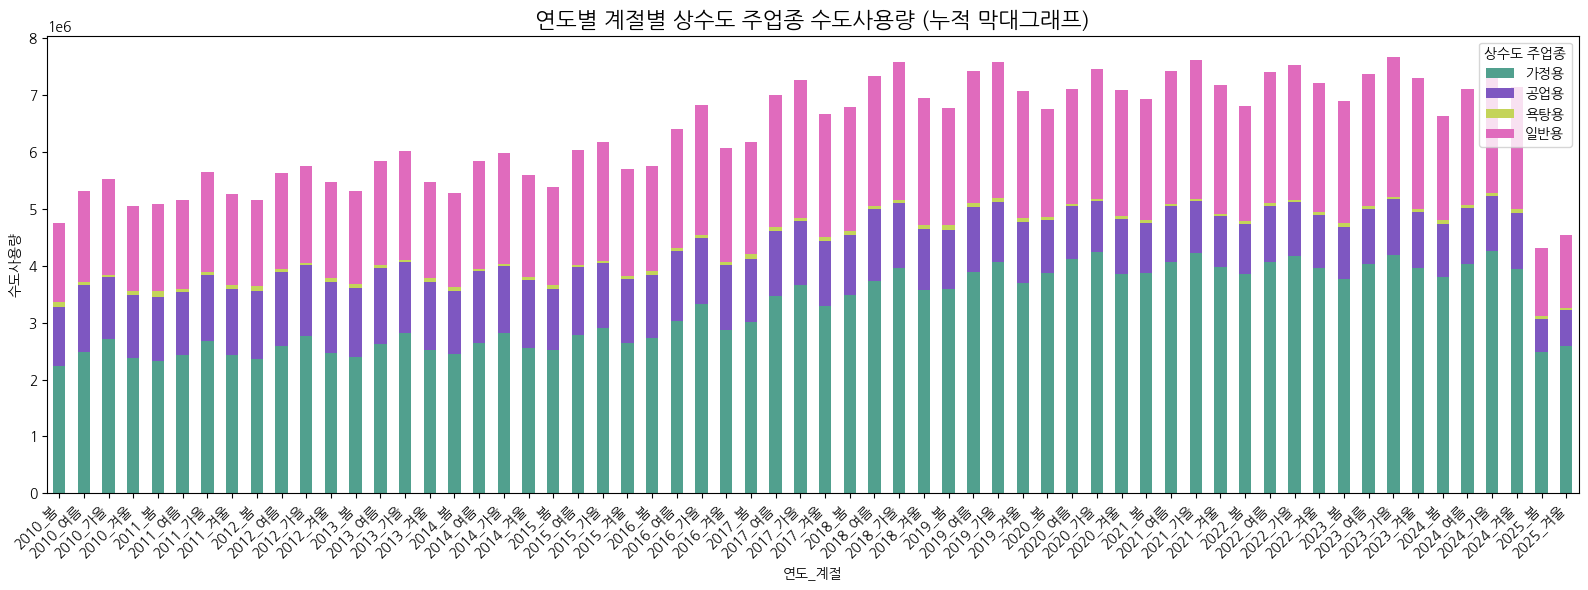

In [ ]:
# 4. 계절별(3-5, 6-8, 9-11, 12-2) : 수도사용량 => 막대그래프

# 월을 계절로 변환하는 컬럼 추가
def get_season(month) :
    if month in [3,4,5]:
        return '봄'
    elif month in [6,7,8]:
        return '여름'
    elif month in [9,10,11]:
        return '가을'
    elif month in [12,1,2]:
        return '겨울'
    
# 계절 컬럼 추가
df_dsg['계절'] = df_dsg['월'].apply(get_season)

# 업종 필터링
target_types = ['가정용', '일반용', '욕탕용', '공업용']
df_filtered = df_dsg[df_dsg['상수도주업종'].isin(target_types)]

# 계절별 업종별 수도사용량 합계
seasonal_usage = df_filtered.groupby(['연도', '계절', '상수도주업종'])['수도사용량'].sum().unstack().fillna(0)

# 계절 순서 지정
season_order = ['봄', '여름', '가을', '겨울']
df_index = seasonal_usage.index.to_frame()
df_index['계절'] = pd.Categorical(df_index['계절'], categories=season_order, ordered=True)
seasonal_usage.index = pd.MultiIndex.from_frame(df_index)
seasonal_usage = seasonal_usage.sort_index()

# x축 라벨을 '연도_계절' 문자열로 변환
seasonal_usage.index = seasonal_usage.index.map(lambda x: f"{x[0]}_{x[1]}")

# 그래프 그리기
seasonal_usage.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    color=["#51a08e", "#7e57c1", "#c4d459", "#e06bbd"]
)

plt.title('연도별 계절별 상수도 주업종 수도사용량 (누적 막대그래프)', fontsize=16)
plt.xlabel('연도_계절')
plt.ylabel('수도사용량')
plt.legend(title='상수도 주업종', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
dfpop2 = pd.read_csv('../data/구군별_세대_및_둥록인구_20250728183121.csv', encoding='cp949')
dfpop2 = dfpop2[dfpop2['행정구역(구군)별(1)'] == '달성군'].set_index('시점')
# ✔ int → float으로 변환해야 NaN 허용됨
# 등록인구를 float로 변환 (결측값 허용)
SR2 = dfpop2['등록인구 (명)'].astype(float)

# 인덱스(시점)를 int로 변환
SR2.index = SR2.index.astype(int)

SR2[2024] = 277204
SR2[2025] = 256376

# 인덱스 정렬
SR2 = SR2.sort_index()

print(SR2)

시점
2010    181623.0
2011    183639.0
2012    187668.0
2013    188085.0
2014    189346.0
2015    197672.0
2016    223585.0
2017    248890.0
2018    256345.0
2019    262580.0
2020    264680.0
2021    267473.0
2022    268788.0
2023    268757.0
2024    277204.0
2025    256376.0
Name: 등록인구 (명), dtype: float64


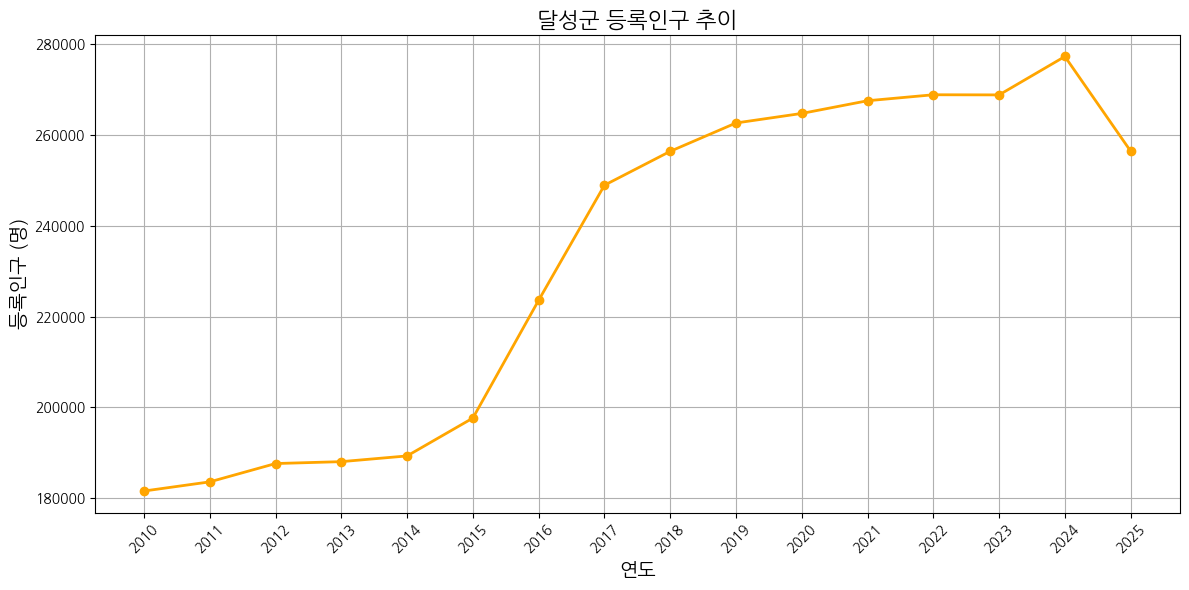

In [ ]:
# 데이터 생성 (시점과 등록인구)
data = {
    2010: 181623.0,
    2011: 183639.0,
    2012: 187668.0,
    2013: 188085.0,
    2014: 189346.0,
    2015: 197672.0,
    2016: 223585.0,
    2017: 248890.0,
    2018: 256345.0,
    2019: 262580.0,
    2020: 264680.0,
    2021: 267473.0,
    2022: 268788.0,
    2023: 268757.0,
    2024: 277204.0,
    2025: 256376.0
}

# Pandas Series로 변환
SR2 = pd.Series(data)

# 그래프 그리기
plt.figure(figsize=(12,6))
plt.plot(SR2.index, SR2.values, marker='o', color='orange', linewidth=2)
plt.title("달성군 등록인구 추이", fontsize=16)
plt.xlabel("연도", fontsize=14)
plt.ylabel("등록인구 (명)", fontsize=14)
plt.grid(True)
plt.xticks(SR2.index, rotation=45)
plt.tight_layout()
plt.show()

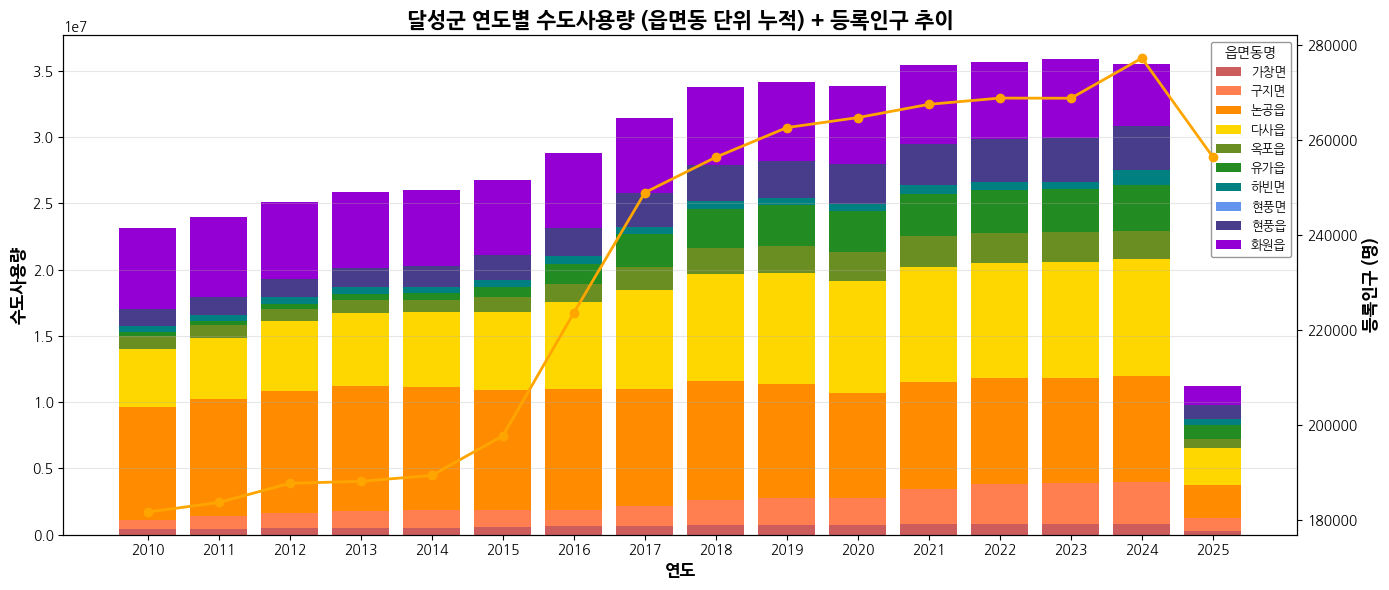

In [62]:
# 달성군 등록인구수와 수도사용량 비교 그래프

# --------------------------------------
# (1) 등록인구 데이터 (2010~2025)
# --------------------------------------
SR2 = pd.Series({
    2010: 181623.0, 2011: 183639.0, 2012: 187668.0,
    2013: 188085.0, 2014: 189346.0, 2015: 197672.0,
    2016: 223585.0, 2017: 248890.0, 2018: 256345.0,
    2019: 262580.0, 2020: 264680.0, 2021: 267473.0,
    2022: 268788.0, 2023: 268757.0, 2024: 277204.0,
    2025: 256376.0
})

# --------------------------------------
# (2) 수도사용량 데이터 준비 (DF → df_dsg)
# --------------------------------------
# 달성군 필터링 (2010~2025)
df_dsg = DF[(DF['시군구명'] == '달성군') & (DF['연도'].between(2010, 2025))].copy()

# '동면리명'에서 앞부분 추출 → '행정단위' 컬럼 생성
df_dsg['행정단위'] = df_dsg['동면리명'].str.split().str[0]

# 연도별-행정단위별 수도사용량 합계 구하기
pivot_df = df_dsg.pivot_table(index='연도',
                               columns='행정단위',
                               values='수도사용량',
                               aggfunc='sum',
                               fill_value=0)

# --------------------------------------
# (3) 시각화: 누적 막대그래프 + 꺾은선 그래프
# --------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))

# 색상 지정 (10개 기준, 부족하면 자동 반복)
colors = ['indianred', 'coral', 'darkorange', 'gold',
          'olivedrab', 'forestgreen', 'teal', 'cornflowerblue',
          'darkslateblue', 'darkviolet']

# 누적 막대그래프
bottom = pd.Series([0]*len(pivot_df), index=pivot_df.index)
for i, dong in enumerate(pivot_df.columns):
    color = colors[i % len(colors)]
    ax1.bar(pivot_df.index,
            pivot_df[dong],
            bottom=bottom,
            label=dong,
            color=color)
    bottom += pivot_df[dong]

# 축/제목 설정
ax1.set_xlabel('연도', fontsize=12, fontweight='bold')
ax1.set_ylabel('수도사용량', fontsize=12, fontweight='bold')
ax1.set_title('달성군 연도별 수도사용량 (읍면동 단위 누적) + 등록인구 추이', fontsize=15, fontweight='bold')
ax1.set_xticks(pivot_df.index)
ax1.tick_params(axis='x', labelrotation=0)
ax1.grid(axis='y', alpha=0.3)

# ✅ 범례 (그래프 안 오른쪽 상단 삽입)
ax1.legend(title='읍면동명',
           loc='upper right',
           fontsize=9,
           title_fontsize=10,
           ncol=1,
           frameon=True,
           facecolor='white',
           edgecolor='gray')

# 꺾은선그래프 (오른쪽 축)
ax2 = ax1.twinx()
ax2.plot(SR2.index, SR2.values,
         color='orange', marker='o', linewidth=2, label='등록인구')
ax2.set_ylabel('등록인구 (명)', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')

# 마무리
plt.tight_layout()
plt.show()
